In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Lab 6 - Fisher's Linear Discriminant and Logistic Regression
- For equations, refer to Bishop's book, Section 4.1.4 and the slides

# Part I - Fisher's Linear Discriminant for Binary Classification (2 classes)

## Data Generation and Visualisation
- First we'll use scikit-learn to generate 2 blobs of data in 2D, using the [make_blobs()](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html) function.
- The data consists of 600 points divided into 2 classes, 0 and 1.

In [2]:
from sklearn.datasets import make_blobs

In [4]:
X, y = make_blobs(n_samples=600, centers=2, n_features=2, random_state=0)

Let's confirm the data has two classes

In [5]:
np.unique(y)

array([0, 1])

## Exercise 1
- Now create a scatter plot to visualise the generated data. 
- Make sure to paint each point based on the class they belong to, as shown in the Figure below.

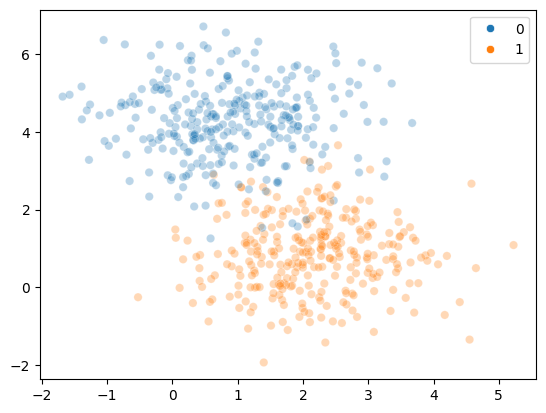

In [129]:
# your code goes here:

ax = sns.scatterplot(
    x=X[:,0],
    y=X[:,1],
    hue=y,
    alpha=0.3
)

leg = ax.legend()
for lh in leg.legend_handles:
    lh.set_alpha(1)

plt.show()



## Exercise 2
* Now plot a histogram of the data projected on each of the 2 dimensions of $X$ ($0$ and $1$)

As an example, below is a figure that shows the projection on dimension $1$.

_Tips:_ 
* You can either use `histplot()` to generate the plot, in which case it might be easier to pack $X$ and $y$ into a pandas DataFrame.
* Alternatively, considering that you will generate this plot many times throughout this lab, you can write a function that takes the projected vector and the class labels.
* Use 30 bins to obtain a similar plot.

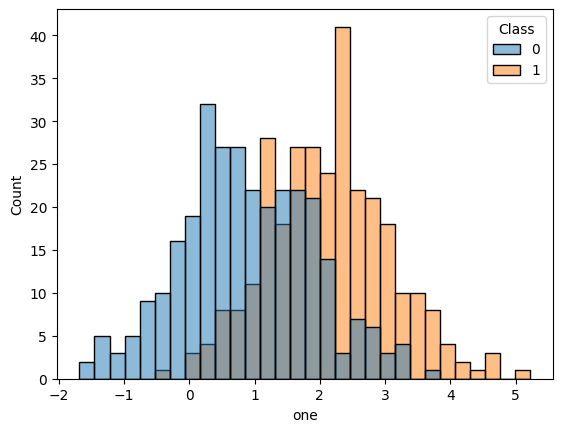

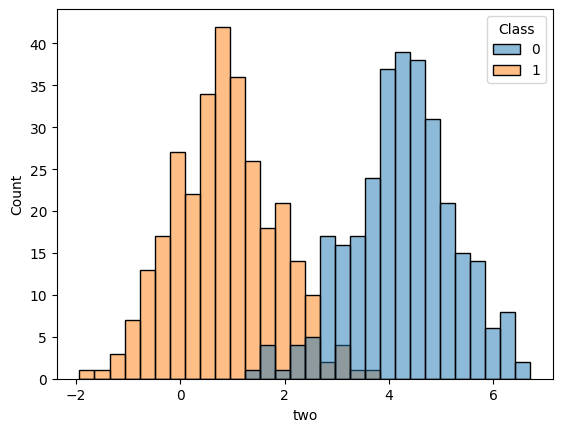

In [169]:
# your code goes here
def plot_proj(Pe_w, y, xlabel = None, stat="count"):
    ax = sns.histplot(
        x=Pe_w,
        hue=y,
        bins=30,
        stat=stat
    )

    ax.set_xlabel(xlabel)
    ax.legend_.set_title("Class")
    plt.show()
    


plot_proj(X[:,0], y, "one")

plot_proj(X[:,1], y, "two")





## Exercise 3 - Implement Fisher's linear discriminant

* Use numpy to calculate $\vec{w}$.
* Plot the data (as you did in Exercise 1), and add a line on the direction of $\vec{w}$ (reference Figure below).
* Project the points onto the calculated vector, and plot the projection (as you did in Exercise 2) (reference Figure below).

In [ ]:
# your code goes here:
def fishers_discriminat(X, y):

    n_fetures = len(X[0])

    c0 = X[y==0]
    c1 = X[y==1]

    size_c0 = sum(y==0)
    size_c1 = sum(y==1)

    m0 = (np.sum(c0, axis=0))/size_c0
    m1 = (np.sum(c1, axis=0))/size_c1

    S_w_c0 = np.zeros((n_fetures,n_fetures))
    S_w_c1 = np.zeros((n_fetures,n_fetures))

    for i in range(size_c0):
        S_w_c0 += ((c0[i] - m0)[:,np.newaxis]).dot((c0[i] - m0)[:,np.newaxis].T)

    for i in range(size_c1):
        S_w_c1 += ((c1[i] - m1)[:,np.newaxis]).dot((c1[i] - m1)[:,np.newaxis].T)

    S_w = S_w_c0 + S_w_c1

    w = np.linalg.inv(S_w)@(m1-m0)

    #normalizado para facilitar a interpretação geometrica da projeção escalar
    w = w.reshape(-1, 1)/np.linalg.norm(w)

    return w 


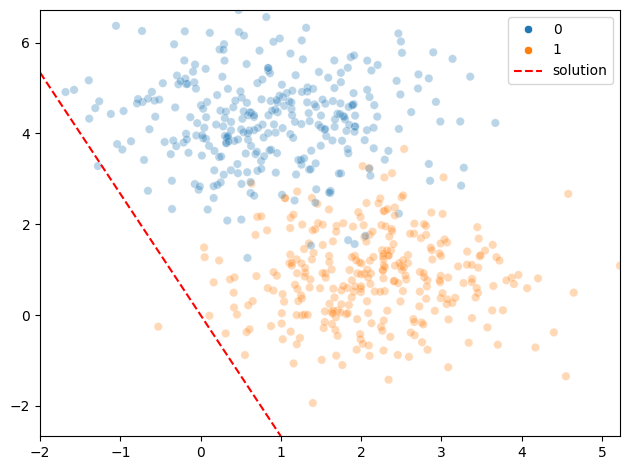

In [141]:
# your code goes here:
w = fishers_discriminat(X, y)
eixo_x = np.linspace(-2, 1, 100)

eixo_y = (w[1]/w[0])*eixo_x

ax = sns.scatterplot(
    x=X[:,0],
    y=X[:,1],
    hue=y,
    alpha=0.3
)

leg = ax.legend()
for lh in leg.legend_handles:
    lh.set_alpha(1)

plt.plot(
    eixo_x,
    eixo_y,
    "--r",
    label="solution"
)

plt.legend()
leg = ax.legend()
for lh in leg.legend_handles:
    lh.set_alpha(1)
    
plt.margins(0)
plt.tight_layout()
plt.show()

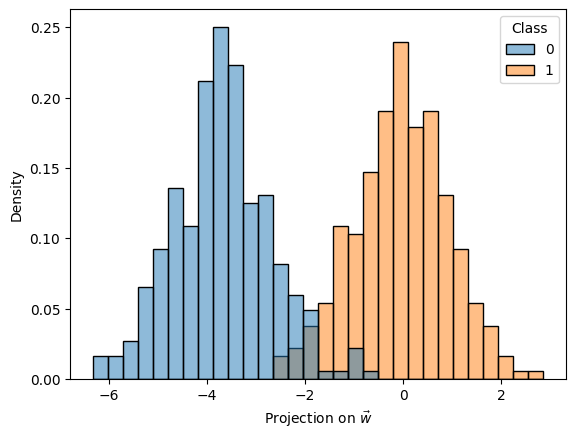

In [150]:
# your code goes here:
Pe_w = X@w

plot_proj(Pe_w[:,0], y, r"Projection on $\vec{w}$", "density")


## Exercise 4

* In this exercise you will use the `RidgeClassifier` from sklearn (as shown below) to obtain the class predictions from different types of projections:
    * component 0 of the data
    * component 1 of the data
    * the calculated vector $\vec{w}$
    
* Calculate the accuracy of these predictions using `accuracy_score` from sklearn.

In [151]:
from sklearn.metrics import accuracy_score
from sklearn.linear_model import RidgeClassifier

In [ ]:
# Follow this structure for each projection:
r = RidgeClassifier()
r.fit(projection, y)
predicted_y = r.predict(projection)
accuracy = accuracy_score(predicted_y, y)

In [157]:
# your code goes here:
component_0 = np.c_[X[:,0], np.zeros_like(X[:,0])]
component_1 = np.c_[np.zeros_like(X[:,1]), X[:,1]]
Pe_w_x0 = X@w

models = [component_0, component_1, Pe_w_x0]

for cada_modelo in models:
    r = RidgeClassifier()
    r.fit(cada_modelo, y)
    predicted_y = r.predict(cada_modelo)
    accuracy = accuracy_score(predicted_y, y)
    print(accuracy)



0.7366666666666667
0.955
0.965


# Part II - Generalised Linear Discriminant (multi-class)

**NOTE:** For this part you will be using a multi-class estimator from scikit-learn (read the [documentation](https://scikit-learn.org/stable/modules/lda_qda.html#lda-qda)).

## Exercise 1 - Generate data

* Generate a 3 classes dataset in 2D, with the same rules as before (make 300 points per class)
* Plot the data and then similar histograms (on each dimension) as Part I Exercises 1 and 2.

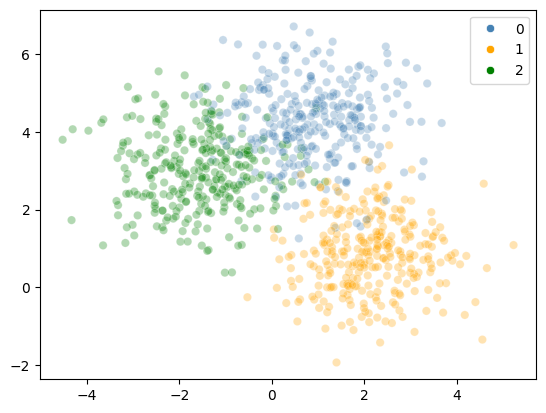

In [170]:
# your code goes here: 
X1, y1 = make_blobs(n_samples=900,centers=3, n_features=2, random_state=0)


ax = sns.scatterplot(
    x=X1[:,0],
    y=X1[:,1],
    hue=y1,
    alpha=0.3,
    palette = ["#4682b4", "#ffa500", "#008000"]
)

leg = ax.legend()
for lh in leg.legend_handles:
    lh.set_alpha(1)

plt.show()


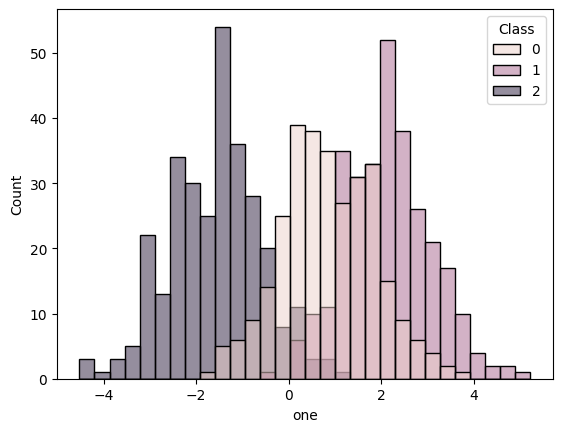

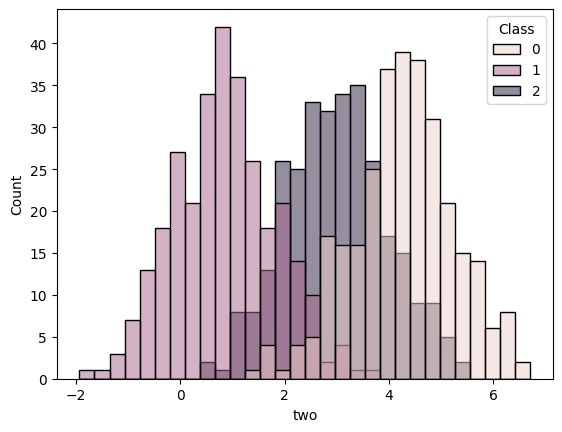

In [171]:
# your code goes here:
plot_proj(X1[:,0], y1, "one")

plot_proj(X1[:,1], y1, "two")

## Exercise 2 - Linear Discriminant Analysis

* Use sklearn's implementation of LDA to project the points in a single dimension and then plot the projected data

In [172]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

Remember that since we want to project our data onto a vector, the parameter n_components of `LinearDiscriminantAnalysis` should be set to 1

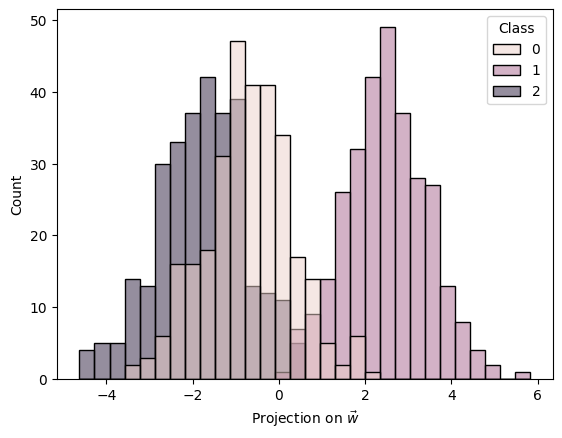

In [ ]:
# your code goes here: 

cfl = LinearDiscriminantAnalysis(n_components=1)
X_proj = cfl.fit_transform(X1, y1)

plot_proj(X_proj[:,0], y1, r"Projection on $\vec{w}$")


## Exercise 3 - Calculate test set accuracy

* use the default parameters for the LDA classifier, and report the prediction accuracy on a train/test split of 70/30% (use `random_state=0`)
* report also the accuracy of the `RidgeClassfier` you used in Part I 

In [180]:
from sklearn.model_selection import train_test_split

In [187]:
# your code goes here:

X_train, X_test, y_train, y_test = train_test_split(
    X1, y1,
    test_size=0.3,
    random_state=0
)

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
y_pred_lda = lda.predict(X_test)
acc_lda = accuracy_score(y_test, y_pred_lda)
print("LDA classifier:", acc_lda)

ridge = RidgeClassifier()
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
acc_ridge = accuracy_score(y_test, y_pred_ridge)
print("Ridge Classifier fitting:", acc_ridge)



LDA classifier: 0.937037037037037
Ridge Classifier fitting: 0.9259259259259259
